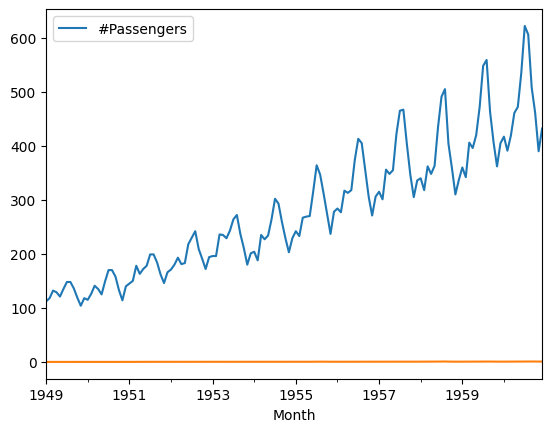

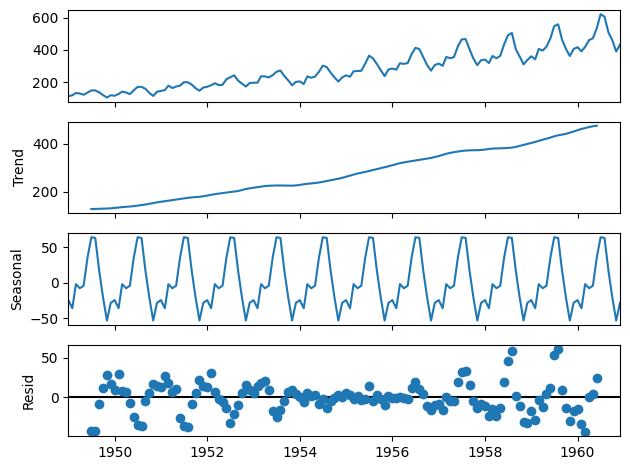

RMSE for test predictions: 0.06953109665118501


Text(0.5, 1.0, 'Prediction')

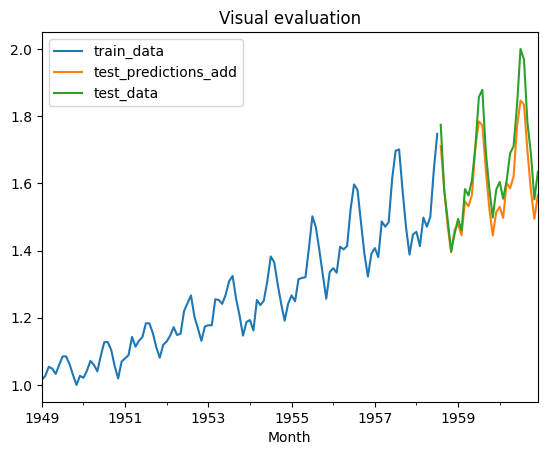

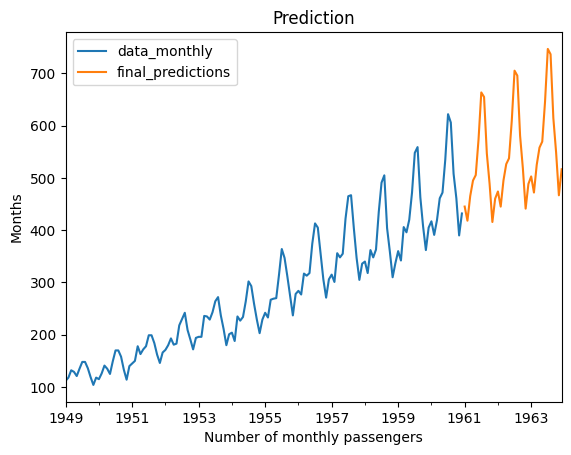

In [ ]:
#Developed By: HAREESH R
#Reg No: 212223230068

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Load the dataset,perform data exploration
data = pd.read_csv('/content/AirPassengers.csv', parse_dates=['Month'],index_col='Month')

data_monthly = data.resample('MS').sum()   #Month start

data_monthly.head()
data_monthly.plot()

# Scale the data and check for seasonality
scaler = MinMaxScaler()
scaled_data = pd.Series(scaler.fit_transform(data_monthly.values.reshape(-1, 1)).flatten(), index=data_monthly.index)
scaled_data.plot() # The data seems to have additive trend and multiplicative seasonality

from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data_monthly, model="additive")
decomposition.plot()
plt.show()

scaled_data=scaled_data+1 # multiplicative seasonality cant handle non postive values, ye
train_data = scaled_data[:int(len(scaled_data) * 0.8)]
test_data = scaled_data[int(len(scaled_data) * 0.8):]
model_add = ExponentialSmoothing(train_data, trend='add', seasonal='mul').fit()
test_predictions_add = model_add.forecast(steps=len(test_data))
ax=train_data.plot()
test_predictions_add.plot(ax=ax)
test_data.plot(ax=ax)
ax.legend(["train_data", "test_predictions_add","test_data"])
ax.set_title('Visual evaluation')
rmse = np.sqrt(mean_squared_error(test_data, test_predictions_add))
print(f"RMSE for test predictions: {rmse}")
np.sqrt(scaled_data.var()),scaled_data.mean()

final_model = ExponentialSmoothing(data_monthly, trend='add', seasonal='mul', seasonal_periods=12).fit()
final_predictions = final_model.forecast(steps=int(len(data_monthly)/4)) #for next year
ax=data_monthly.plot()
final_predictions.plot(ax=ax)
ax.legend(["data_monthly", "final_predictions"])
ax.set_xlabel('Number of monthly passengers')
ax.set_ylabel('Months')
ax.set_title('Prediction')